In [6]:
from guardian_help import *

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, f1_score, confusion_matrix,
    recall_score, precision_score, accuracy_score,
)
from sklearn.ensemble import IsolationForest
from scipy.stats import skew, kurtosis, entropy

path = "./data/"
path_users = path + "users/"

users = [name for name in os.listdir(path + "users/") if os.path.isdir(os.path.join(path + "users/", name))]
print(users)

['0043er', '0724er', '0811ne', '0972rs', '1613ey', '1744an', '1776yy', '1848ne', '1864nw', '1875td', '1947ne', '2005dh', '2006nh', '2009dl', '2017ae', '2024er', '2025es', '2029ny', '2030nr', '2033kt', '2037sn', '2039nn', '2065ey', '2072ds', '2081lo', '2086ty', '2094ne', '2103en', '2112el', '2130oa', '2133lr', '2139ha', '2141po', '2144dl', '2152so', '2153ng', '2157ss', '2158yn', '2160rz', '2168hd', '2172lt', '2176as', '2180yr', '2221ee', '2237ns', '2270er', '2278te', '2327wn', '2367oo', '2401er', '2464ys', '2700hm', '2702SZ', '2703le', '2719sn', '2720dn', '2753nt', '2764hn', '2775ar', '2781yh', '2789ly', '2792sl', '2802ln']


## Kinematic Features

In [16]:
feature_cols_kinematic = [
        "number_out_of_screen",
        "d_mean",
        "d_entropy",
        "v_mean",
        "v_entropy",
        "a_mean",
    ]

def shannon_entropy(data):
    data = data.dropna()
    bins = np.unique(np.nanpercentile(data, np.linspace(0, 100, 21)))
    hist, _ = np.histogram(data, bins=bins)
    p = hist / hist.sum()
    p = p[p > 0]
    return -np.sum(p * np.log2(p))

def extract_kinematic_features(df_video):
    features = {}

    features["user"] = df_video.user.iloc[0]
    features["genre_category"] = df_video.genre_category.iloc[0]
    features["video_number"] = df_video.video_number.iloc[0]
    features["number_out_of_screen"] = df_video['number_out_of_screen'].sum()

    features['d_mean'] = df_video['dist'].mean()
    features['d_entropy'] = shannon_entropy(df_video['dist'])

    features['v_mean'] = df_video['real_velocity'].mean()
    features['v_entropy'] = shannon_entropy(df_video['real_velocity'])

    dv = df_video['real_velocity'].diff()
    acceleration = dv / (df_video['dt'] + 1e-9)
    features['a_mean'] = acceleration.mean()

    return features


def get_kinematic_features(df_window):
    dict_kinematic_features = {}
    count = 0
    for user in users:
        print(f"Processing user {user} ({users.index(user)+1}/{len(users)})", end='\r')
        df_user = df_window[df_window['user'] == user]

        for video_number in df_user['video_number'].unique():
            df_video = df_user[df_user['video_number'] == video_number].copy()

            df_video[['x', 'y']] = df_video[['x', 'y']].replace(-32768, np.nan)
            df_video[['x', 'y']] = df_video[['x', 'y']].replace(32768, np.nan)
            df_video["number_out_of_screen"] = df_video[['x', 'y']].isna().any(axis=1).astype(int)
            df_video[['x', 'y']] = df_video[['x', 'y']].interpolate()

            df_video['dt'] = df_video['timestamp'].diff() / 1000.0
            df_video['dx'] = df_video['x'].diff()
            df_video['dy'] = df_video['y'].diff()
            df_video['dist'] = np.sqrt(df_video['dx']**2 + df_video['dy']**2)
            df_video['real_velocity'] = df_video['dist'] / (df_video['dt'] + 1e-9)

            features = extract_kinematic_features(df_video)
            dict_kinematic_features[count] = features
            count += 1

    return pd.DataFrame.from_dict(dict_kinematic_features, orient='index')


## High-Level Features

### Function definitions

In [17]:
def euclidean_distance_calculation(row):
    # compute Euclidean distance between consecutive gaze points
    val = math.sqrt((row['x'] - row['shifted_x']) ** 2 + (row['y'] - row['shifted_y']) ** 2)
    return val

def visual_angle_calculation(row, distance_to_screen=1000):
    # compute visual angle based on gaze distance and screen distance
    angle = 2 * math.atan((row['gaze_distance (mm)']) / (2 * distance_to_screen))
    deg = math.degrees(angle)
    return deg

def time_delta_calculation(row):
    # difference between current and next timestamps
    delta = row['shifted_timestamp'] - row['timestamp']
    return delta

def velocity_calculation(row):
    # velocity as visual angle per second
    vel = float(row['visual_angle (°)'] / (float(row['time_delta (ms)'] / 1000)))
    return vel

def label_gaze_velocities(row, velocity_threshold=30):
    # label as fixation (1) if below threshold else saccade (0)
    label = 1 if row['velocity (°/s)'] < velocity_threshold else 0
    return label

def define_eye_fixations(data_group):
    # skip groups with long time gaps
    if data_group['timestamp'].diff().max() > 100:
        return pd.Series({'Start time (ms)': np.nan, 'Fixation x (mm)': np.nan, 'Fixation y (mm)': np.nan,
                          'Duration (ms)': np.nan, 'Label': np.nan, 'User': np.nan, 'Video': np.nan,
                          'Velocity (°/s)': np.nan})
    # compute fixation centroid and stats
    x_axis = np.mean(data_group['x'])
    y_axis = np.mean(data_group['y'])
    start_time = float(data_group['timestamp'].iloc[0])
    end_time = float(data_group['timestamp'].iloc[-1])
    duration = end_time - start_time
    gaze_label = data_group['gaze_labels'].iloc[0]
    user = data_group['user'].iloc[0]
    velocity = data_group.loc[:, "velocity (°/s)"].mean()
    return pd.Series({'Start time (ms)': start_time, 'Fixation x (mm)': x_axis, 'Fixation y (mm)': y_axis,
                      'Duration (ms)': duration, 'Label': gaze_label, 'User': user,
                      'Video': data_group['video_number'].iloc[0], 'Velocity (°/s)': velocity})

def merge_adjacent_fixations(data, max_gap_ms=20):
    # merge consecutive fixations separated by small gaps
    merged_fixations = []
    current_fixation = None
    for _, row in data.iterrows():
        if row['Label'] == 1:
            if current_fixation is None:
                current_fixation = row
            else:
                gap = row['Start time (ms)'] - (current_fixation['Start time (ms)'] + current_fixation['Duration (ms)'])
                if gap <= max_gap_ms:
                    # merge fixations
                    current_fixation['Duration (ms)'] += gap + row['Duration (ms)']
                    current_fixation['Fixation x (mm)'] = (current_fixation['Fixation x (mm)'] + row['Fixation x (mm)']) / 2
                    current_fixation['Fixation y (mm)'] = (current_fixation['Fixation y (mm)'] + row['Fixation y (mm)']) / 2
                    current_fixation['Velocity (°/s)'] = (current_fixation['Velocity (°/s)'] + row['Velocity (°/s)']) / 2
                else:
                    merged_fixations.append(current_fixation)
                    current_fixation = row
    if current_fixation is not None:
        merged_fixations.append(current_fixation)
    return pd.DataFrame(merged_fixations)

def get_fixation_stats(data_group):
    # compute fixation count, mean duration, and entropy for spatial distribution
    fixation_number = len(data_group['Fixation x (mm)'])
    duration = np.mean(data_group['Duration (ms)'])
    hist, _, _ = np.histogram2d(data_group['Fixation x (mm)'], data_group['Fixation y (mm)'], bins=fixation_number)
    p = hist.flatten()
    p = p[p > 0]
    p = p / p.sum()
    entropy = -np.sum(p * np.log2(p))
    
    return pd.Series({'number': fixation_number, 'mean duration': duration, 'entropy': entropy,
                      'video': data_group['Video'].iloc[0], 'user': data_group['User'].iloc[0]})

def calculate_acceleration(df):
    # compute acceleration as velocity change over time between saccades
    df['Acceleration (°/s)'] = (df['Velocity (°/s)'] - df['Velocity (°/s)'].shift(1)) / (df['Start time (ms)'] - df['Start time (ms)'].shift(1)) / 1000
    return df

def label_gaze_acceleration(row):
    # label positive acceleration as 1 else 0
    label = 1 if row['Acceleration (°/s)'] >= 0 else 0
    return label

def define_eye_saccade(data_group):
    # summarize saccade start/end points and stats
    start_x = float(data_group['Fixation x (mm)'].iloc[0])
    start_y = float(data_group['Fixation y (mm)'].iloc[0])
    end_x = float(data_group['Fixation x (mm)'].iloc[-1])
    end_y = float(data_group['Fixation y (mm)'].iloc[-1])
    distance = math.sqrt((start_x - end_x) ** 2 + (start_y - end_y) ** 2)
    start_time = float(data_group['Start time (ms)'].iloc[0])
    end_time = float(data_group['Start time (ms)'].iloc[-1])
    duration = end_time - start_time
    gaze_label = data_group['gaze_labels'].iloc[0]
    user = data_group['User'].iloc[0]
    velocity = data_group.loc[:, "Velocity (°/s)"].mean()
    return pd.Series({'Start time (ms)': start_time, 'Saccade start x (mm)': start_x, 'Saccade start y (mm)': start_y,
                      'Saccade end x (mm)': end_x, 'Saccade end y (mm)': end_y, 'Duration (ms)': duration,
                      'Amplitude (mm)': distance, 'Label': gaze_label, 'User': user,
                      'Video': data_group['Video'].iloc[0], 'Velocity (°/s)': velocity})

def get_saccade_stats(data_group):
    # compute saccade aggregate statistics
    saccade_number = len(data_group['Saccade start x (mm)'])
    duration = np.mean(data_group['Duration (ms)'])
    velocity = np.mean(data_group['Velocity (°/s)'])
    amplitude = np.mean(data_group['Amplitude (mm)'])
    return pd.Series({'number': saccade_number, 'duration': duration, 'velocity': velocity,
                      'amplitude': amplitude, 'video': data_group['Video'].iloc[0], 'user': data_group['User'].iloc[0]})


### Load the data and extract fixation and saccade statistics per user

In [18]:
feature_cols_gaze = [
            'mean_duration_fix', 
            'entropy_fix', 
            'number_sac', 
            'duration_sac', 
            'velocity_sac', 
            'amplitude_sac']

def obtain_gaze_features(df_gaze):
    df_window = df_gaze.copy()

    df_gaze_set_aux = pd.DataFrame()
    count_empty_users = 0
    for user in users:  # iterate target users
        data_user = df_window[df_window['user'] == user].copy()

        saccade_data_all = pd.DataFrame()
        fixation_data_all = pd.DataFrame()
        count = 0
        
        # print percentage of users processed
        print(f"Processing user {user} ({users.index(user)+1}/{len(users)})", end='\r')
        count_video = 0
        for video in data_user['video_number'].unique():  # iterate videos for this user

            count_video += 1
            df_video = data_user[data_user['video_number'] == video].copy()

            data = df_video.copy()  # filter data for user and video   
            data = data.drop(['genre_category', 'missing', 'pupil_area'], axis=1)

            # Interpolate missing values
            data['x'].replace({-32768: np.nan}, inplace=True)
            data['y'].replace({-32768: np.nan}, inplace=True)
            data['x'].replace({32768: np.nan}, inplace=True)
            data['y'].replace({32768: np.nan}, inplace=True)
            data[['x', 'y']] = data[['x', 'y']].interpolate()

            # Screen dimensions
            px_screen_x, px_screen_y = 2560, 1440
            mm_screen_x, mm_screen_y = 6000, 3400

            # Convert coordinates to millimeters
            data['x'] = data['x'] * (mm_screen_x / px_screen_x)
            data['y'] = data['y'] * (mm_screen_y / px_screen_y)

            # Create shifted columns
            data = pd.concat([data, data.shift(-1).add_prefix('shifted_')], axis=1).iloc[:-1, :]

            # Calculate gaze metrics
            data.insert(len(data.columns), "gaze_distance (mm)", data.apply(euclidean_distance_calculation, axis=1))
            data.insert(len(data.columns), "visual_angle (°)", data.apply(visual_angle_calculation, axis=1))
            data.insert(len(data.columns), "time_delta (ms)", data.apply(time_delta_calculation, axis=1))
            data.insert(len(data.columns), "velocity (°/s)", data.apply(velocity_calculation, axis=1))
            data.insert(len(data.columns), "gaze_labels", data.apply(label_gaze_velocities, axis=1))
            data.index.name = None

            # Extract fixations
            gaze_bool = data['gaze_labels'].ne(data['gaze_labels'].shift())
            data = data.groupby(gaze_bool.cumsum()).apply(define_eye_fixations).dropna()

            # Separate saccades
            saccade_data = data.loc[data['Label'] == 0].copy()
            
            # Process fixations
            fixation_data = merge_adjacent_fixations(data)

            if fixation_data.empty or saccade_data.empty:
                count_empty_users += 1
                continue
            
            fixation_data = fixation_data.loc[fixation_data['Label'] == 1]
            
            # Remove outliers
            if len(fixation_data) > 5:
                upper = fixation_data['Duration (ms)'].quantile(0.99)
                lower = fixation_data['Duration (ms)'].quantile(0.01)
                fixation_data = fixation_data[(fixation_data['Duration (ms)'] >= lower) & (fixation_data['Duration (ms)'] <= upper)]

            # Fixation statistics (per video)
            fixation_stats = get_fixation_stats(fixation_data)
            fixation_stats_aux = fixation_stats.T
            fixation_data_all[count] = fixation_stats_aux

            # Process saccades
            saccade_data = saccade_data[~saccade_data['Start time (ms)'].isin(fixation_data['Start time (ms)'] + fixation_data['Duration (ms)'])]
            saccade_data = calculate_acceleration(saccade_data)
            saccade_data.insert(len(saccade_data.columns), "gaze_labels", saccade_data.apply(label_gaze_acceleration, axis=1))
            saccade_data['gaze_bool'] = saccade_data['gaze_labels'] > saccade_data['gaze_labels'].shift(1)
            saccade_data = saccade_data.groupby(saccade_data['gaze_bool'].cumsum()).apply(define_eye_saccade)
            
            # Remove outliers
            if len(saccade_data) > 5:
                upper = saccade_data['Duration (ms)'].quantile(0.99)
                lower = saccade_data['Duration (ms)'].quantile(0.01)
                saccade_data = saccade_data[(saccade_data['Duration (ms)'] >= lower) & (saccade_data['Duration (ms)'] <= upper)]
            

            # Saccade statistics (per video)
            saccade_stats = get_saccade_stats(saccade_data)
            saccade_stats_aux = saccade_stats.T
            saccade_data_all[count] = saccade_stats_aux
            
            count += 1

        df_fixations = fixation_data_all.T
        df_saccades = saccade_data_all.T

        # merge fixations and saccades dataframes on video column
        df_fix_sac = pd.merge(df_fixations, df_saccades, on=['video'], suffixes=('_fix', '_sac'))
        df_fix_sac["video"] = df_fix_sac["video"].astype(int)
        df_fix_sac['user'] = user
        # rename video column to video_number
        df_fix_sac = df_fix_sac.rename(columns={'video': 'video_number', 
                                            'mean duration': 'mean_duration_fix', 
                                            'entropy': 'entropy_fix',
                                            'duration': 'duration_sac',
                                            'amplitude': 'amplitude_sac',
                                            'velocity': 'velocity_sac',
                                            })
        # merge df_fix_sac with df_test on user and video_number
        df_gaze_set_aux = pd.concat([df_gaze_set_aux, df_fix_sac], ignore_index=True)

    return df_gaze_set_aux


## Authentication

In [19]:
# --- Hyperparameters ---
TEST_SIZE = 0.3
BASELINE_TRAINING_RATIO = 0.7
RANDOM_STATE = 42
N_ESTIMATORS = 100
CONTAMINATION_RATE = "auto"

# --- Helper: tune threshold on training scores ---
def tune_threshold(clf, X_train, X_eval, y_eval, percentiles=np.linspace(1, 20, 20)):
    scores_train = clf.decision_function(X_train)
    scores_eval = clf.decision_function(X_eval)

    best = {"score": -np.inf}
    f1_scores, recalls, fp_rates = [], [], []

    for p in percentiles:
        thr = np.percentile(scores_train, p)
        y_pred = (scores_eval < thr).astype(int)  # 1 = anomaly
        recall = recall_score(y_eval, y_pred, zero_division=0)
        fp_rate = np.sum((y_eval == 0) & (y_pred == 1)) / max(np.sum(y_eval == 0), 1)
        f1 = f1_score(y_eval, y_pred, zero_division=0)

        f1_scores.append(f1)
        recalls.append(recall)
        fp_rates.append(fp_rate)

        if f1 > best["score"]:
            best = {
                "score": f1,
                "percentile": p,
                "threshold": thr,
                "y_pred": y_pred,
                "recall": recall,
                "fp_rate": fp_rate,
                "f1": f1,
                "f1_series": f1_scores,
                "recall_series": recalls,
                "fp_series": fp_rates,
            }
    return best

def authentication_user_detection(df_users_cv, feature_cols):
    # Keep only available columns to prevent KeyError
    available_feature_cols = [c for c in feature_cols if c in df_users_cv.columns]
    missing_cols = set(feature_cols) - set(available_feature_cols)
    if missing_cols:
        print(f"Warning: dropping unavailable features {missing_cols}")

    X = df_users_cv[available_feature_cols]
    y = df_users_cv["user"]

    # --- Scaling ---
    scaler = StandardScaler()
    X_scaled_full = scaler.fit_transform(X)
    df_scaled = pd.DataFrame(X_scaled_full, columns=available_feature_cols)
    df_scaled["user"] = df_users_cv["user"].values
    df_scaled["video_number"] = df_users_cv["video_number"].values


    # --- Storage for global evaluation ---
    f1_results = []
    precision_results = []
    recall_results = []
    fp_rate_results = []
    accuracy_results = []
    cm_tp = cm_fp = cm_tn = cm_fn = 0

    # --- Train & evaluate per user ---
    for target_user in users:
        print(f"Processing user {users.index(target_user)+1} of {len(users)}", end='\r')

        known_user_df = df_scaled[df_scaled["user"] == target_user].copy()
        watched_videos = known_user_df["video_number"].unique()

        if len(watched_videos) < 2:
            print("Not enough videos for train/test split, skipping.")
            continue

        train_videos, test_videos = train_test_split(
            watched_videos,
            train_size=BASELINE_TRAINING_RATIO,
            random_state=RANDOM_STATE,
        )

        X_train = known_user_df[known_user_df["video_number"].isin(train_videos)][available_feature_cols]
        X_leftover = known_user_df[known_user_df["video_number"].isin(test_videos)][available_feature_cols]

        # --- Build test set: known + unknown users ---
        test_set_df = df_scaled[
            (~df_scaled["user"].isin([target_user])) | (df_scaled.index.isin(X_leftover.index))
        ].copy()

        X_test = test_set_df[available_feature_cols]
        y_true = np.where(~test_set_df["user"].isin([target_user]), 1, 0)

        # --- Train Isolation Forest ---
        clf = IsolationForest(
            n_estimators=N_ESTIMATORS,
            contamination=CONTAMINATION_RATE,
            random_state=RANDOM_STATE,
        ).fit(X_train)

        # --- Initial prediction (for report) ---
        y_pred_if = clf.predict(X_test)
        y_pred_mapped = np.where(y_pred_if == -1, 1, 0)

        # --- Novelty detection rate ---
        novel_mask = test_set_df["user"].isin([target_user]) == False
        novel_pred = clf.predict(X_test[novel_mask])
        novelty_detection_rate = np.mean(novel_pred == -1)

        # --- Threshold tuning ---
        best = tune_threshold(clf, X_train, X_test, y_true)
        best_percentile = best["percentile"]
        best_threshold = best["threshold"]
        y_pred_best = best["y_pred"]

        # --- Metrics with tuned threshold ---
        accuracy = accuracy_score(y_true, y_pred_best)
        precision = precision_score(y_true, y_pred_best, zero_division=0)
        recall = recall_score(y_true, y_pred_best, zero_division=0)
        f1 = f1_score(y_true, y_pred_best, zero_division=0)

        cm = confusion_matrix(y_true, y_pred_best)
        cm_df = pd.DataFrame(
            cm,
            index=["Actual Normal (0)", "Actual Anomaly (1)"],
            columns=["Pred Normal (0)", "Pred Anomaly (1)"],
        )
        
        # --- Store per-user results ---
        f1_results.append(f1)
        recall_results.append(recall)
        fp_rate_results.append(best["fp_rate"])
        accuracy_results.append(accuracy)
        precision_results.append(precision)

        cm_tp += cm[1, 1]
        cm_tn += cm[0, 0]
        cm_fp += cm[0, 1]
        cm_fn += cm[1, 0]

    # --- Global evaluation ---
    print("\n=== GLOBAL EVALUATION ACROSS ALL USERS ===")
    print(f"Final Average Accuracy : {np.mean(accuracy_results):.4f}")
    print(f"Final Average Precision: {np.mean(precision_results):.4f}")
    print(f"Final Average Recall   : {np.mean(recall_results):.4f}")
    print(f"Final Average F1 Score : {np.mean(f1_results):.4f}")

    cm_df = pd.DataFrame(
        [[cm_tn, cm_fp], [cm_fn, cm_tp]],
        index=["Actual Normal (0)", "Actual Anomaly (1)"],
        columns=["Pred Normal (0)", "Pred Anomaly (1)"],
    )
    print("Aggregated Confusion matrix (rows = actual, columns = predicted):")
    print(cm_df)

    return {
        "accuracy": np.mean(accuracy_results),
        "precision": np.mean(precision_results),
        "recall": np.mean(recall_results),
        "f1_score": np.mean(f1_results),
        
    }, f1_results


In [20]:
dict_all_users_data = load_all_users_data(path_users)
df_users = get_all_users_df(dict_all_users_data)
df_users['video_number'] = df_users['video_number'].astype(int) 

Processing user 0043er (1/63)
Processing user 0724er (2/63)
Processing user 0811ne (3/63)
Processing user 0972rs (4/63)
Processing user 1613ey (5/63)
Processing user 1744an (6/63)
Processing user 1776yy (7/63)
Processing user 1848ne (8/63)
Processing user 1864nw (9/63)
Processing user 1875td (10/63)
Processing user 1947ne (11/63)
Processing user 2005dh (12/63)
Processing user 2006nh (13/63)
Processing user 2009dl (14/63)
Processing user 2017ae (15/63)
Processing user 2024er (16/63)
Processing user 2025es (17/63)
Processing user 2029ny (18/63)
Processing user 2030nr (19/63)
Processing user 2033kt (20/63)
Processing user 2037sn (21/63)
Processing user 2039nn (22/63)
Processing user 2065ey (23/63)
Processing user 2072ds (24/63)
Processing user 2081lo (25/63)
Processing user 2086ty (26/63)
Processing user 2094ne (27/63)
Processing user 2103en (28/63)
Processing user 2112el (29/63)
Processing user 2130oa (30/63)
Processing user 2133lr (31/63)
Processing user 2139ha (32/63)
Processing user 2

### Effect of Downsampling

In [21]:
windom_limit = 5

results_freq= {}
f1_scores_freq = {}

for sampling_rate in [1, 15, 30, 60]:

    auth_results = {}
    f1_scores_all = {}

    SAMPLING_RATE = sampling_rate  # Hz

    print("\n\tRunning authentication with kinematic features...")
    df_window = df_users.copy()

    df_window_resampled = pd.DataFrame()
    
    print("Downsampling to", SAMPLING_RATE, "Hz...")
    for (user, video_number), group in df_window.groupby(['user', 'video_number']):
        
        df_user_video = group.copy()
        data = df_user_video.copy()# # downsample to target sampling rate
        data["bin"] = np.floor(data["timestamp"] / (1000 / SAMPLING_RATE))
        data = data.groupby("bin", as_index=False).first() # Keep the first row in each bin
        data = data.drop(columns=["bin"])

        # retain only the first 1000 rows
        data = data.head(windom_limit*SAMPLING_RATE+1)
        df_window_resampled = pd.concat([df_window_resampled, data], ignore_index=True)
        
    print(len(df_window_resampled), "rows in the windowed dataframe.")
    df_kinematic_features = get_kinematic_features(df_window=df_window_resampled)

    results_kinematic, f1_kinematic = authentication_user_detection(df_kinematic_features, feature_cols_kinematic)
    auth_results[f"kinematic_{windom_limit}"] = results_kinematic
    f1_scores_all[f"kinematic_{windom_limit}"] = f1_kinematic

    print("\n\tRunning authentication with gaze features...")
    df_gaze_features = obtain_gaze_features(df_gaze=df_window_resampled)
    if df_gaze_features.empty:
        continue
    
    results_gaze, f1_gaze = authentication_user_detection(df_gaze_features, feature_cols_gaze)

    auth_results[f"gaze_{windom_limit}"] = results_gaze
    f1_scores_all[f"gaze_{windom_limit}"] = f1_gaze
    results_freq[f"{SAMPLING_RATE}hz"] = auth_results
    f1_scores_freq[f"{SAMPLING_RATE}hz"] = f1_scores_all



	Running authentication with kinematic features...
Downsampling to 1 Hz...
15588 rows in the windowed dataframe.
Processing user 63 of 6363/63)
=== GLOBAL EVALUATION ACROSS ALL USERS ===
Final Average Accuracy : 0.2697
Final Average Precision: 0.9952
Final Average Recall   : 0.2673
Final Average F1 Score : 0.4104
Aggregated Confusion matrix (rows = actual, columns = predicted):
                    Pred Normal (0)  Pred Anomaly (1)
Actual Normal (0)               598               187
Actual Anomaly (1)           118025             43051

	Running authentication with gaze features...
Processing user 63 of 6363/63)
=== GLOBAL EVALUATION ACROSS ALL USERS ===
Final Average Accuracy : 0.2251
Final Average Precision: 0.9946
Final Average Recall   : 0.2220
Final Average F1 Score : 0.3409
Aggregated Confusion matrix (rows = actual, columns = predicted):
                    Pred Normal (0)  Pred Anomaly (1)
Actual Normal (0)               218                53
Actual Anomaly (1)            394

#### Line Chart
**Plot line chart for metrics (no subsampling), both feature sets on the same graph**

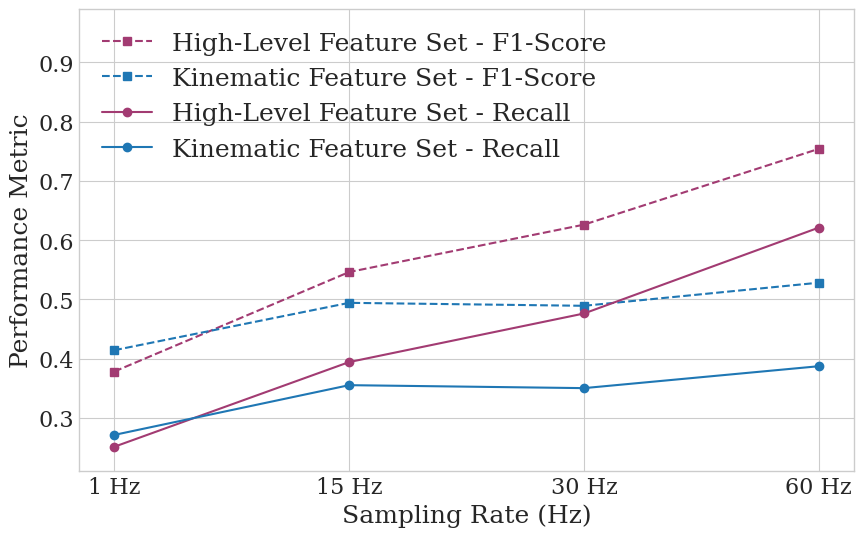

In [ ]:
window_limit = 5
sampling_rates = list(results_freq.keys())

x_labels = [f"{int(float(str(sr).replace('hz', '')))} Hz" for sr in sampling_rates]
x_positions = range(len(sampling_rates))

plt.figure(figsize=(10, 6))

for metric in ["f1_score", "recall"]:
    row_kinematic, row_gaze = [], []

    for sr in sampling_rates:
        key_k = f"kinematic_{window_limit}"
        key_g = f"gaze_{window_limit}"

        d = results_freq[sr][key_k] if key_k in results_freq[sr] else None
        d_g = results_freq[sr][key_g] if key_g in results_freq[sr] else None

        row_kinematic.append(d.get(metric, np.nan) if d is not None else np.nan)
        row_gaze.append(d_g.get(metric, np.nan) if d_g is not None else np.nan)

    line_data_kinematic = pd.DataFrame({'Sampling Rate (Hz)': sampling_rates, metric: row_kinematic})
    line_data_gaze = pd.DataFrame({'Sampling Rate (Hz)': sampling_rates, metric: row_gaze})

    if metric == "f1_score":
        style_kinematic = style_gaze = '--'
        marker = 'o'
        metric_ = "F1-Score"
    else:
        style_kinematic = style_gaze = '-'
        marker = 's'
        metric_ = "Recall"
    
    plt.plot(line_data_kinematic['Sampling Rate (Hz)'], line_data_kinematic[metric],
             marker=marker, linestyle=style_kinematic,
             label=f"Kinematic Feature Set - {metric_}", color='#2E86AB')
    plt.plot(line_data_gaze['Sampling Rate (Hz)'], line_data_gaze[metric],
             marker=marker, linestyle=style_gaze,
             label=f"High-level Feature Set - {metric_}", color='#A23B72')

ax = plt.gca()
plt.xlabel('Sampling Rate (Hz)')
plt.ylabel("Performance Metric")
plt.grid(True)
plt.ylim(0.21, 0.99)
plt.legend()
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels)

plt.show()

#### Heatmap
**Plot results heatmap for F1 scores (kinematic and gaze in the same figure)**

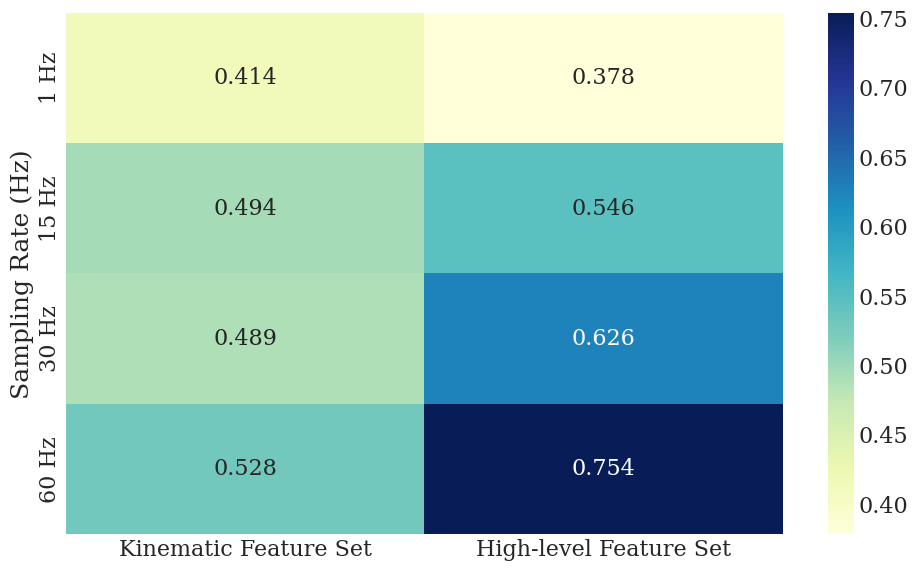

In [ ]:
import seaborn as sns

windom_limit = 5
metric = "f1_score"

heatmap_data_kinematic = pd.DataFrame()
heatmap_data_gaze = pd.DataFrame()

for sampling_rate in results_freq.keys():
    row_kinematic, row_gaze = [], []
    key_k = f"kinematic_{windom_limit}"
    row_kinematic.append(results_freq[sampling_rate][key_k][metric] if key_k in results_freq[sampling_rate] else np.nan)

    key_g = f"gaze_{windom_limit}"
    row_gaze.append(results_freq[sampling_rate][key_g][metric] if key_g in results_freq[sampling_rate] else np.nan)

    heatmap_data_kinematic = pd.concat(
        [heatmap_data_kinematic, pd.DataFrame([row_kinematic], index=[sampling_rate])]
    )
    heatmap_data_gaze = pd.concat(
        [heatmap_data_gaze, pd.DataFrame([row_gaze], index=[sampling_rate])]
    )

heatmap_data_kinematic.columns = [windom_limit]
heatmap_data_gaze.columns = [windom_limit]

# Combine both dataframes side by side
heatmap_combined = pd.concat([heatmap_data_kinematic, heatmap_data_gaze], axis=1, keys=['Kinematic Feature Set', 'High-level Feature Set'])

# Remove "-5s" suffix from column names by flattening and renaming
heatmap_combined.columns = heatmap_combined.columns.droplevel(1)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
sns.heatmap(heatmap_combined, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax)

ax.set_ylabel("Sampling Rate (Hz)")
ax.set_yticklabels([f"{int(float(rate.replace('hz', '')))} Hz" for rate in heatmap_combined.index])

plt.tight_layout()
plt.show()

### Effect of Window Size (No Downsampling)

In [ ]:
windom_limits = [0.1, 1, 10, 30]

auth_results_window = {}
f1_scores_all_window = {}

for windom_limit in windom_limits:
    print(f"\n\n\t--- Processing window limit: {windom_limit} seconds ---\n")
    min_ts = df_users.groupby(['user', 'video_number'])['timestamp'].transform('min')
    df_window_resampled = df_users[df_users['timestamp'] - min_ts <= windom_limit * 1000].reset_index(drop=True)

    print("\n\tRunning authentication with kinematic features...")
    print(len(df_window_resampled), "rows in the windowed dataframe.")
    df_kinematic_features = get_kinematic_features(df_window=df_window_resampled)

    results_kinematic, f1_kinematic = authentication_user_detection(df_kinematic_features, feature_cols_kinematic)
    auth_results_window[f"kinematic_{windom_limit}"] = results_kinematic
    f1_scores_all_window[f"kinematic_{windom_limit}"] = f1_kinematic

    print("\n\tRunning authentication with gaze features...")
    df_gaze_features = obtain_gaze_features(df_gaze=df_window_resampled)
    if df_gaze_features.empty:
        continue
    
    results_gaze, f1_gaze = authentication_user_detection(df_gaze_features, feature_cols_gaze)
    auth_results_window[f"gaze_{windom_limit}"] = results_gaze
    f1_scores_all_window[f"gaze_{windom_limit}"] = f1_gaze




	--- Processing window limit: 0.1 seconds ---


	Running authentication with kinematic features...
78411 rows in the windowed dataframe.
Processing user 63 of 6363/63)
=== GLOBAL EVALUATION ACROSS ALL USERS ===
Final Average Accuracy : 0.5199
Final Average Precision: 0.9960
Final Average Recall   : 0.5185
Final Average F1 Score : 0.6383
Aggregated Confusion matrix (rows = actual, columns = predicted):
                    Pred Normal (0)  Pred Anomaly (1)
Actual Normal (0)               634               151
Actual Anomaly (1)            77543             83533

	Running authentication with gaze features...
Processing user 63 of 6363/63)
=== GLOBAL EVALUATION ACROSS ALL USERS ===
Final Average Accuracy : 0.5440
Final Average Precision: 0.9974
Final Average Recall   : 0.5427
Final Average F1 Score : 0.6774
Aggregated Confusion matrix (rows = actual, columns = predicted):
                    Pred Normal (0)  Pred Anomaly (1)
Actual Normal (0)               550               153
Actual A

#### Line Chart

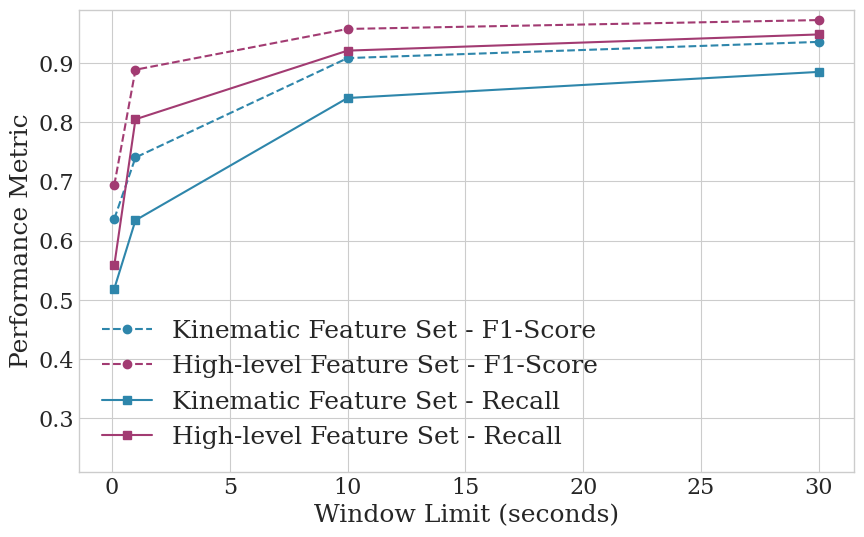

In [ ]:
plt.figure(figsize=(10, 6))

for metric in ["f1_score", "recall"]:
    row_kinematic, row_gaze = [], []
    for wl in [0.1, 1, 10, 30]:
        key_k = f"kinematic_{wl}"
        key_g = f"gaze_{wl}"
        if metric == "f1_score":
            row_kinematic.append(np.mean(f1_scores_all_window[key_k]) if key_k in f1_scores_all_window else np.nan)
            row_gaze.append(np.mean(f1_scores_all_window[key_g]) if key_g in f1_scores_all_window else np.nan)
        else:
            row_kinematic.append(auth_results_window[key_k][metric] if key_k in auth_results_window else np.nan)
            row_gaze.append(auth_results_window[key_g][metric] if key_g in auth_results_window else np.nan)

    line_data_kinematic = pd.DataFrame({'Window Limit (s)': [0.1, 1, 10, 30], metric: row_kinematic})
    line_data_gaze = pd.DataFrame({'Window Limit (s)': [0.1, 1, 10, 30], metric: row_gaze})

    if metric == "f1_score":
        style_kinematic = '--'
        style_gaze = '--'
        marker = 'o'
        metric_ = "F1-Score"
    else:
        style_kinematic = '-'
        style_gaze = '-'
        marker = 's'
        metric_ = "Recall"
    # color for kinematic: #2E86AB (blue), gaze: #A23B72 (purple/magenta)
    plt.plot(line_data_kinematic['Window Limit (s)'], line_data_kinematic[metric],
             marker=marker, linestyle=style_kinematic, label=f"Kinematic Feature Set - {metric_}", color='#2E86AB')
    plt.plot(line_data_gaze['Window Limit (s)'], line_data_gaze[metric],
             marker=marker, linestyle=style_gaze, label=f"High-level Feature Set - {metric_}", color='#A23B72')
plt.xlabel('Window Limit (seconds)')
plt.ylabel("Performance Metric")
plt.xticks(windom_limits, [str(w) for w in windom_limits])
plt.grid(True)
plt.legend()
plt.ylim(0.21, 0.99)
plt.xscale('linear')

plt.show()

#### Heatmap

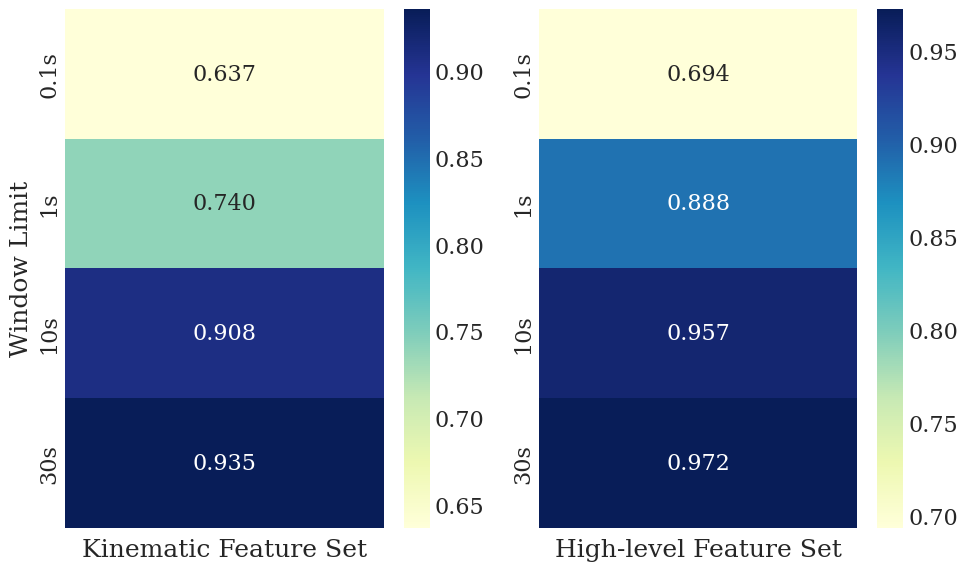

In [ ]:
metric = "f1_score"

heatmap_data_kinematic = pd.DataFrame()
heatmap_data_gaze = pd.DataFrame()

row_kinematic, row_gaze = [], []
for windom_limit in windom_limits:
    key_k = f"kinematic_{windom_limit}"
    key_g = f"gaze_{windom_limit}"
    row_kinematic.append(auth_results_window[key_k][metric] if key_k in auth_results_window else np.nan)
    row_gaze.append(auth_results_window[key_g][metric] if key_g in auth_results_window else np.nan)

heatmap_data_kinematic = pd.DataFrame([row_kinematic], columns=[f"{w}s" for w in windom_limits]).T
heatmap_data_gaze = pd.DataFrame([row_gaze], columns=[f"{w}s" for w in windom_limits]).T

fig, axes = plt.subplots(1, 2, figsize=(10, 6))
sns.heatmap(heatmap_data_kinematic, annot=True, fmt=".3f", cmap="YlGnBu", ax=axes[0], cbar=True)
axes[0].set_ylabel("Window Limit")
axes[0].set_xlabel("Kinematic Feature Set")
axes[0].set_xticks([0.5])
axes[0].set_xticklabels([""])

sns.heatmap(heatmap_data_gaze, annot=True, fmt=".3f", cmap="YlGnBu", ax=axes[1], cbar=True)
axes[1].set_ylabel("")
axes[1].set_xlabel("High-level Feature Set")
axes[1].set_xticks([0.5])
axes[1].set_xticklabels([""])

# Remove 0 from x-axis ticks if present
for ax in axes:
    xticks = ax.get_xticks()
    xticklabels = [label.get_text() for label in ax.get_xticklabels()]
    if "0" in xticklabels:
        ax.set_xticklabels([l if l != "0" else "" for l in xticklabels])

plt.tight_layout()
plt.show()